# Abstract Base Class - inference

The inference pipeline is designed to be run independently after the training pipeline.
- predict() is model-specific. It loads test_processed from cache, runs models on test data, and saves predictions as CSV
- evaluate() loads the saved predictions, computes evaluation metrics and saves the results.

This notebook walks though the different steps of the evaluate function. If you dont want to run the linear example, skip to section 2: Test your subclass.

In [1]:
import os
import json
import pickle
import torch 
import torch.nn as nn
import numpy as np
import pandas as pd
from base_model import BaseModel

# Linear example

In [2]:
class LinearModel(BaseModel):

    @property
    def model_name(self): return "linear"

    def preprocess(self):
        for attr, df in [('train_processed', self.train_raw),
                         ('val_processed',   self.val_raw),
                         ('test_processed',  self.test_raw)]:
            sample = df.sample(n=min(50_000, len(df)), random_state=self.SEED)
            X = torch.tensor(
                sample[['wday', 'month', 'sell_price', 'is_available']].values,
                dtype=torch.float32
            )
            y = torch.tensor(
                np.log1p(sample['sales'].values), dtype=torch.float32
            ).unsqueeze(1)
            setattr(self, attr, (X, y))

    def train(self, epochs=50, lr=1e-2):
        X_train, y_train = self.train_processed
        X_val,   y_val   = self.val_processed

        self.model = nn.Linear(X_train.shape[1], 1).to(self.device)
        optimiser  = torch.optim.Adam(self.model.parameters(), lr=lr)
        loss_fn    = nn.MSELoss()

        for epoch in range(epochs):
            self.model.train()
            optimiser.zero_grad()
            loss_fn(self.model(X_train.to(self.device)), y_train.to(self.device)).backward()
            optimiser.step()

            with torch.no_grad():
                val_loss = loss_fn(
                    self.model(X_val.to(self.device)), y_val.to(self.device)
                ).item()
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1:02d}/{epochs} | val MSE (log1p): {val_loss:.4f}")

        torch.save(self.model.state_dict(),
                   os.path.join(self.output_dir, f"{self.model_name}.pth"))

    def predict(self) -> pd.DataFrame:
        # 1. Load weights
        weights_path = os.path.join(self.output_dir, f"{self.model_name}.pth")
        self.model   = nn.Linear(4, 1).to(self.device)
        self.model.load_state_dict(torch.load(weights_path, map_location=self.device))
        self.model.eval()

        # 2. Build features from target window (d_1914–d_1941)
        target = self.test_raw[self.test_raw['d_num'] >= self.TARGET_START].copy()
        X = torch.tensor(
            target[['wday', 'month', 'sell_price', 'is_available']].values,
            dtype=torch.float32
        )

        # 3. Inference in log1p space → expm1 back to sales space
        with torch.no_grad():
            log_preds   = self.model(X.to(self.device)).cpu().numpy().flatten()
            point_preds = np.expm1(log_preds).clip(min=0)

        # 4. All quantiles equal to point prediction (deterministic model)
        q_cols   = [f"q{q}" for q in self.QUANTILES]
        preds_df = target[['id', 'd_num']].copy().reset_index(drop=True)
        preds_df['day_ahead'] = preds_df['d_num'] - self.TARGET_START + 1
        for col in q_cols:
            preds_df[col] = point_preds

        # 5. Enforce non-decreasing quantiles >= 0
        preds_df[q_cols] = (
            preds_df[q_cols]
            .clip(lower=0)
            .apply(lambda row: np.maximum.accumulate(row.values),
                   axis=1, result_type='expand')
            .set_axis(q_cols, axis=1)
        )

        # 6. Sort and save
        preds_df = (
            preds_df[['id', 'day_ahead'] + q_cols]
            .sort_values(['id', 'day_ahead'])
            .reset_index(drop=True)
        )
        out_path = os.path.join(self.output_dir, f"{self.model_name}_predictions.csv")
        preds_df.to_csv(out_path, index=False)
        print(f"Predictions saved to {out_path}")
        return preds_df

In [3]:
m = LinearModel()
m.run_training_pipeline()

Loaded cached data splits.
Finished shared data processing.
Finished model-specific data processing.
Epoch 10/50 | val MSE (log1p): 3.9367
Epoch 20/50 | val MSE (log1p): 2.1178
Epoch 30/50 | val MSE (log1p): 1.9633
Epoch 40/50 | val MSE (log1p): 1.5745
Epoch 50/50 | val MSE (log1p): 1.2252
Finished model training.


# 1. Evaluation (WIP)

In [4]:
# Step 1: load train_raw, test_raw, item_weights from cache (or run load_and_split_data if not cached)
data_dir = "data"
cache    = os.path.join(data_dir, "raw_split.pkl")
assert os.path.exists(cache), "Run load_and_split_data() first to generate the cache."

with open(cache, "rb") as f:
    d = pickle.load(f)

train_raw    = d["train_raw"]
test_raw     = d["test_raw"]
item_weights = d["item_weights"]

print(f"train_raw:    {train_raw.shape}")
print(f"test_raw:     {test_raw.shape}")
print(f"item_weights: {item_weights.shape}")

train_raw:    (54058770, 24)
test_raw:     (1707440, 24)
item_weights: (30490,)


In [5]:
# Step 2: load previously saved model predictions
# replace this with your own model name!

model_name = "linear"  # see abc_train-yen.ipnb for this example
output_dir = "outputs"
preds_path = os.path.join(output_dir, f"{model_name}_predictions.csv")
assert os.path.exists(preds_path), "Run predict() first to generate predictions."

preds_df = pd.read_csv(preds_path)

print(f"preds_df shape: {preds_df.shape}")          # (853720, 11)
print(f"Columns: {preds_df.columns.tolist()}")
print(preds_df.sample(5))

preds_df shape: (853720, 11)
Columns: ['id', 'day_ahead', 'q0.025', 'q0.05', 'q0.1', 'q0.25', 'q0.5', 'q0.75', 'q0.9', 'q0.95', 'q0.975']
                                     id  day_ahead    q0.025     q0.05  \
294385      FOODS_3_439_CA_4_evaluation         22  0.690998  0.690998   
518557    HOBBIES_1_423_WI_3_evaluation         26  1.435826  1.435826   
559054    HOBBIES_2_144_TX_3_evaluation          7  0.896613  0.896613   
337200      FOODS_3_592_CA_3_evaluation         25  0.923614  0.923614   
662263  HOUSEHOLD_1_371_CA_3_evaluation          8  0.233547  0.233547   

            q0.1     q0.25      q0.5     q0.75      q0.9     q0.95    q0.975  
294385  0.690998  0.690998  0.690998  0.690998  0.690998  0.690998  0.690998  
518557  1.435826  1.435826  1.435826  1.435826  1.435826  1.435826  1.435826  
559054  0.896613  0.896613  0.896613  0.896613  0.896613  0.896613  0.896613  
337200  0.923614  0.923614  0.923614  0.923614  0.923614  0.923614  0.923614  
662263  0.233547  0.23

In [6]:
# Step 3: extract test targets
TARGET_START = 1914
PRED_LENGTH  = 28
QUANTILES    = [0.025, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.975]
q_cols       = [f"q{q}" for q in QUANTILES]

# Targets: pivot test_raw to (N, 28)
targets = (
    test_raw[test_raw['d_num'] >= TARGET_START]
    .pivot(index='id', columns='d_num', values='sales')
    .sort_index()
)
ids   = targets.index.tolist()
y_mat = targets.values.astype(np.float32)

print(f"y_mat shape: {y_mat.shape}")       # (30490, 28)
print(f"Sample targets:\n{y_mat[:3, :5]}")

y_mat shape: (30490, 28)
Sample targets:
[[2. 0. 0. 0. 0.]
 [0. 3. 0. 0. 0.]
 [1. 0. 1. 0. 8.]]


In [ ]:
# Step 4: transform predictions into arrays for more efficient pinball loss calculation
q_arr = (
    preds_df.set_index(['id', 'day_ahead'])[q_cols]
    .unstack('day_ahead')
    .unstack('day_ahead').sort_index(axis=1).loc[ids]
    .values.reshape(len(ids), len(QUANTILES), PRED_LENGTH)
)

print(f"q_arr shape: {q_arr.shape}")       # (30490, 9, 28)
print(f"Quantiles for series 25, day 25: {q_arr[25, :, 25]}")   # should be non-decreasing

q_arr shape: (30490, 9, 28)
Quantiles for series 25, day 25: [4.0658584 4.0658584 4.0658584 4.0658584 4.0658584 4.0658584 4.0658584
 4.0658584 4.0658584]


In the winning paper (Eq. 5), we scale pinball loss by the in-sample mean absolute day-to-day change. This penalises errors less if the series (sales pattern for that item) is more volatile. 
- clip(lower=1e-8) prevents 0 or inf WSPL from a single bad prediction from an item with zero sales during the training window

In [8]:
# Step 5: calculate scale
train_sorted = train_raw.sort_values(['id', 'd_num']).copy()
train_sorted['prev_sales'] = train_sorted.groupby('id')['sales'].shift(1)

scale = (
    train_sorted.dropna(subset=['prev_sales'])
    .assign(abs_diff=lambda df: (df['sales'] - df['prev_sales']).abs())
    .groupby('id')['abs_diff']
    .mean()
    .clip(lower=1e-8)  # avoid division by zero for flat/zero series
)
print(scale.describe())
print(f"Zero-clipped series: {(scale <= 1e-8).sum()}")

count    3.049000e+04
mean     9.074526e-01
std      1.289095e+00
min      1.000000e-08
25%      2.550790e-01
50%      5.395034e-01
75%      1.054176e+00
max      4.194018e+01
Name: abs_diff, dtype: float64
Zero-clipped series: 27


In [9]:
# Step 6: create pinball loss tensors - used by WSPL and CRPS 
q_vals  = np.array(QUANTILES)                                  # (9,)
errors  = y_mat[:, None, :] - q_arr                            # (N, 9, 28)
pinball = np.maximum(q_vals[None, :, None] * errors,
                     (q_vals[None, :, None] - 1) * errors)     # (N, 9, 28)

print(f"Pinball shape: {pinball.shape}")   # (30490, 9, 28)
print(f"Min pinball (should be >= 0): {pinball.min():.6f}")

Pinball shape: (30490, 9, 28)
Min pinball (should be >= 0): -0.000000


In [10]:
# ! pip install matplotlib

Mean pinball per quantile:
[0.97226022 0.97219013 0.97204996 0.97162943 0.97092856 0.97022768
 0.96980715 0.96966698 0.96959689]


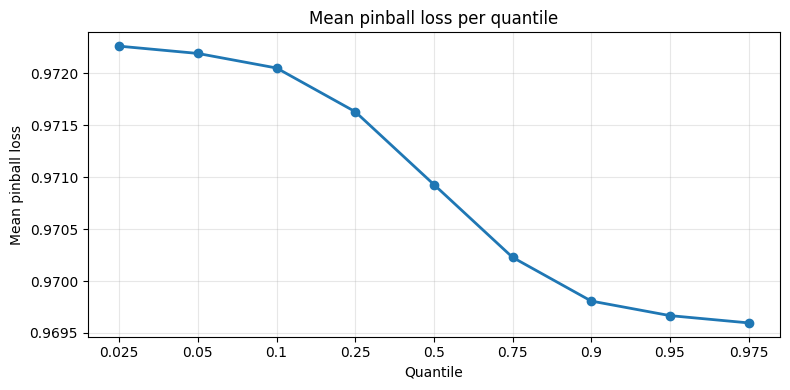

In [11]:
# Sense check plot, not for submission
# expect U-shape, lowest at q0.5

import matplotlib.pyplot as plt

print(f"Mean pinball per quantile:\n{pinball.mean(axis=(0,2))}")
q_labels        = [str(q) for q in QUANTILES]
mean_per_quantile = pinball.mean(axis=(0, 2))

plt.figure(figsize=(8, 4))
plt.plot(q_labels, mean_per_quantile, marker='o', linewidth=2)
plt.xlabel("Quantile")
plt.ylabel("Mean pinball loss")
plt.title("Mean pinball loss per quantile")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Step 7: compute WSPL
# Scale pinball loss by MAE per series, then take revenue-weighted sum across series
QUANTILES = [0.025, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.975]

wspl_per_series = pinball.mean(axis=(1, 2)) / scale.reindex(ids).values   # (N,)
weights         = item_weights.reindex(ids).fillna(0).values               # (N,)
wspl            = float(np.dot(weights, wspl_per_series))

print(f"WSPL: {wspl:.6f}")
print(f"WSPL per series — mean: {wspl_per_series.mean():.4f}, "
      f"max: {wspl_per_series.max():.4f}, "
      f"worst series: {ids[wspl_per_series.argmax()]}")

WSPL: 1.604414
WSPL per series — mean: 58490.8788, max: 115498992.7679, worst series: FOODS_3_296_WI_2_evaluation


Since we only predict 9 quantiles, we approximate CRPS using 2*mean pinball loss. This doesnt use any scaling and stays in units of sales so we can interpret it directly e.g. CRPS of 5.18 means our average prediction error is 5.18 units

In [13]:
# Step 8: compute CRPS
def compute_crps(y_mat, q_arr, ids) -> float:
    q_vals  = np.array(QUANTILES)
    errors  = y_mat[:, None, :] - q_arr   # (N, 9, 28)
    pinball = np.maximum(q_vals[None, :, None] * errors,
                         (q_vals[None, :, None] - 1) * errors)
    crps_per_series = 2 * pinball.mean(axis=(1, 2))
    weights = item_weights.reindex(ids).fillna(0).values
    return float(np.dot(weights, crps_per_series))

crps = compute_crps(y_mat, q_arr, ids)

print(f"CRPS: {crps:.6f}")
# Sanity check: CRPS should be in units of sales (roughly similar magnitude to mean sales)
print(f"Mean daily sales for reference: {y_mat.mean():.4f}")

CRPS: 5.188051
Mean daily sales for reference: 1.4428


In [14]:
# Step 9: compute coverage error
# For each interval, check what fraction of true values (empirical coverage) fall inside prediction intervals, 
# then subtract the target probability (nominal coverage) e.g. 95%.
intervals = {
    0.50: ("q0.25",  "q0.75"),
    0.80: ("q0.1",   "q0.9"),
    0.90: ("q0.05",  "q0.95"),
    0.95: ("q0.025", "q0.975"),
}

preds_indexed = (
    preds_df.set_index(['id', 'day_ahead'])
    .reindex(pd.MultiIndex.from_product(
        [ids, range(1, PRED_LENGTH + 1)],
        names=['id', 'day_ahead']))
)

for nominal, (lower_col, upper_col) in intervals.items():
    lower   = preds_indexed[lower_col].values.reshape(len(ids), PRED_LENGTH)
    upper   = preds_indexed[upper_col].values.reshape(len(ids), PRED_LENGTH)
    covered = ((y_mat >= lower) & (y_mat <= upper)).mean()
    error   = covered - nominal
    print(f"{int(nominal*100)}% interval — actual coverage: {covered:.4f}, "
          f"error: {error:+.4f}")

50% interval — actual coverage: 0.1234, error: -0.3766
80% interval — actual coverage: 0.1234, error: -0.6766
90% interval — actual coverage: 0.1234, error: -0.7766
95% interval — actual coverage: 0.1234, error: -0.8266


- A well-calibrated model should have all 4 errors close to 0. 
- A deterministic model (like the linear example) will have all quantiles equal, so will show large negative coverage errors because its intervals have 0 width.

In [15]:
# Step 10: compile all results
coverage_errors = {}
for nominal, (lower_col, upper_col) in intervals.items():
    lower   = preds_indexed[lower_col].values.reshape(len(ids), PRED_LENGTH)
    upper   = preds_indexed[upper_col].values.reshape(len(ids), PRED_LENGTH)
    covered = ((y_mat >= lower) & (y_mat <= upper)).mean()
    coverage_errors[f"coverage_error_{int(nominal*100)}pct"] = round(float(covered - nominal), 6)

results = {
    "model" : "linear",
    "wspl"  : round(wspl, 6),
    "crps"  : round(crps, 6),
    **coverage_errors,
}
print(json.dumps(results, indent=2))

{
  "model": "linear",
  "wspl": 1.604414,
  "crps": 5.188051,
  "coverage_error_50pct": -0.376648,
  "coverage_error_80pct": -0.676648,
  "coverage_error_90pct": -0.776648,
  "coverage_error_95pct": -0.826648
}


## 1.1 Define evaluate function + helper functions

In [16]:
# Combine steps 3-6
def _build_pinball_tensor(self, preds_df: pd.DataFrame):
    """
    Shared setup for WSPL and CRPS. Requires self.train_raw, self.test_raw.
    Returns y_mat (N,28), q_arr (N,9,28), ids, scale.
    """
    q_cols  = [f"q{q}" for q in self.QUANTILES]
    
    # Extract test targets for d_1914-d_1941 (28 days)
    test_targets = (
        self.test_raw[self.test_raw['d_num'] >= self.TARGET_START]
        .pivot(index='id', columns='d_num', values='sales')
        .sort_index()
    )
    ids = test_targets.index.tolist()
    y_mat = test_targets.values.astype(np.float32)  # Shape: (N_series, 28)
    
    # Reshape predictions to match
    preds_pivot = (
        preds_df.set_index(['id', 'day_ahead'])[q_cols]
        .unstack('day_ahead')
        .sort_index(axis=1) 
        .loc[ids])
    q_arr = preds_pivot.values.reshape(len(ids), len(self.QUANTILES), self.PRED_LENGTH)
    
    # Scale from train
    train_s = self.train_raw.sort_values(['id', 'd_num']).copy()
    train_s['prev'] = train_s.groupby('id')['sales'].shift(1)
    scale = (
        train_s.dropna(subset=['prev'])
        .assign(abs_diff=lambda df: (df['sales'] - df['prev']).abs())
        .groupby('id')['abs_diff']
        .mean()
        .reindex(ids)  # Align scale to test data IDs
        .clip(lower=1e-8)
    )
    
    # Checks for debugging
    assert y_mat.shape == (len(ids), 28), f"y_mat shape mismatch: {y_mat.shape}"
    assert q_arr.shape == (len(ids), 9, 28), f"q_arr shape mismatch: {q_arr.shape}"
    
    return y_mat, q_arr, ids, scale

In [17]:
# Steps 7-9: metrics

def compute_wspl(self, y_mat, q_arr, ids, scale) -> float:
    """Weighted scaled pinball loss across 9 quantiles and 28 forecast days."""
    q_vals  = np.array(self.QUANTILES)
    errors  = y_mat[:, None, :] - q_arr
    pinball = np.maximum(q_vals[None, :, None] * errors,
                         (q_vals[None, :, None] - 1) * errors)
    wspl_per_series = pinball.mean(axis=(1, 2)) / scale.reindex(ids).values
    weights         = self.item_weights.reindex(ids).fillna(0).values
    return float(np.dot(weights, wspl_per_series))


def compute_crps(self, y_mat, q_arr, ids) -> float:
    q_vals  = np.array(self.QUANTILES)
    errors  = y_mat[:, None, :] - q_arr   # (N, 9, 28)
    pinball = np.maximum(q_vals[None, :, None] * errors,
                         (q_vals[None, :, None] - 1) * errors)
    crps_per_series = 2 * pinball.mean(axis=(1, 2))
    weights = self.item_weights.reindex(ids).fillna(0).values
    return float(np.dot(weights, crps_per_series))


def compute_coverage(self, preds_df: pd.DataFrame, y_mat, ids) -> dict:
    """
    Coverage error (actual - nominal) for 4 prediction intervals.
    Positive = over-coverage, negative = under-coverage.
    """
    intervals = {
        0.50: ("q0.25",  "q0.75"),
        0.80: ("q0.1",   "q0.9"),
        0.90: ("q0.05",  "q0.95"),
        0.95: ("q0.025", "q0.975"),
    }
    preds_indexed = (
        preds_df.set_index(['id', 'day_ahead'])
        .reindex(pd.MultiIndex.from_product(
            [ids, range(1, self.PRED_LENGTH + 1)],
            names=['id', 'day_ahead']))
    )
    coverage_errors = {}
    for nominal, (lower_col, upper_col) in intervals.items():
        lower   = preds_indexed[lower_col].values.reshape(len(ids), self.PRED_LENGTH)
        upper   = preds_indexed[upper_col].values.reshape(len(ids), self.PRED_LENGTH)
        covered = ((y_mat >= lower) & (y_mat <= upper)).mean()
        coverage_errors[f"coverage_error_{int(nominal*100)}pct"] = round(
            float(covered - nominal), 6)
    return coverage_errors

In [18]:
def evaluate(self, preds_df: pd.DataFrame) -> dict:
    """
    Compute WSPL, CRPS and coverage error from a predictions DataFrame.
    Saves results to output_dir/{model_name}_results.json.
    Requires: raw_split.pkl in data_dir (run load_and_split_data() first).
    """
    cache = os.path.join(self.data_dir, "raw_split.pkl")
    assert os.path.exists(cache), "Run load_and_split_data() first."
    with open(cache, "rb") as f:
        d = pickle.load(f)
    self.train_raw    = d["train_raw"]
    self.test_raw     = d["test_raw"]
    self.item_weights = d["item_weights"]

    y_mat, q_arr, ids, scale = self._build_pinball_tensor(preds_df)

    results = {
        "model" : self.model_name,
        "wspl"  : round(self.compute_wspl(y_mat, q_arr, ids, scale), 6),
        "crps"  : round(self.compute_crps(y_mat, q_arr, ids), 6),
        **self.compute_coverage(preds_df, y_mat, ids),
    }

    out_path = os.path.join(self.output_dir, f"{self.model_name}_results.json")
    with open(out_path, "w") as f:
        json.dump(results, f, indent=2)
    print(json.dumps(results, indent=2))
    return results

# 2. Test your subclass

In [1]:
# Restart the kernel and make sure the below code runs on its own
import os
import json
import pickle
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from base_model import BaseModel

In [2]:
# Replace this with your subclass
class LinearModel(BaseModel):

    @property
    def model_name(self): return "linear"

    def preprocess(self):
        for attr, df in [('train_processed', self.train_raw),
                         ('val_processed',   self.val_raw),
                         ('test_processed',  self.test_raw)]:
            sample = df.sample(n=min(50_000, len(df)), random_state=self.SEED)
            X = torch.tensor(
                sample[['wday', 'month', 'sell_price', 'is_available']].values,
                dtype=torch.float32
            )
            y = torch.tensor(
                np.log1p(sample['sales'].values), dtype=torch.float32
            ).unsqueeze(1)
            setattr(self, attr, (X, y))

    def train(self, epochs=50, lr=1e-2):
        X_train, y_train = self.train_processed
        X_val,   y_val   = self.val_processed

        self.model = nn.Linear(X_train.shape[1], 1).to(self.device)
        optimiser  = torch.optim.Adam(self.model.parameters(), lr=lr)
        loss_fn    = nn.MSELoss()

        for epoch in range(epochs):
            self.model.train()
            optimiser.zero_grad()
            loss_fn(self.model(X_train.to(self.device)), y_train.to(self.device)).backward()
            optimiser.step()

            with torch.no_grad():
                val_loss = loss_fn(
                    self.model(X_val.to(self.device)), y_val.to(self.device)
                ).item()
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1:02d}/{epochs} | val MSE (log1p): {val_loss:.4f}")

        torch.save(self.model.state_dict(),
                   os.path.join(self.output_dir, f"{self.model_name}.pth"))

    def predict(self) -> pd.DataFrame:
        # 1. Load weights
        weights_path = os.path.join(self.output_dir, f"{self.model_name}.pth")
        self.model   = nn.Linear(4, 1).to(self.device)
        self.model.load_state_dict(torch.load(weights_path, map_location=self.device))
        self.model.eval()

        # 2. Build features from target window (d_1914–d_1941)
        target = self.test_raw[self.test_raw['d_num'] >= self.TARGET_START].copy()
        X = torch.tensor(
            target[['wday', 'month', 'sell_price', 'is_available']].values,
            dtype=torch.float32
        )

        # 3. Inference in log1p space → expm1 back to sales space
        with torch.no_grad():
            log_preds   = self.model(X.to(self.device)).cpu().numpy().flatten()
            point_preds = np.expm1(log_preds).clip(min=0)

        # 4. All quantiles equal to point prediction (deterministic model)
        q_cols   = [f"q{q}" for q in self.QUANTILES]
        preds_df = target[['id', 'd_num']].copy().reset_index(drop=True)
        preds_df['day_ahead'] = preds_df['d_num'] - self.TARGET_START + 1
        for col in q_cols:
            preds_df[col] = point_preds

        # 5. Enforce non-decreasing quantiles >= 0
        preds_df[q_cols] = (
            preds_df[q_cols]
            .clip(lower=0)
            .apply(lambda row: np.maximum.accumulate(row.values),
                   axis=1, result_type='expand')
            .set_axis(q_cols, axis=1)
        )

        # 6. Sort and save
        preds_df = (
            preds_df[['id', 'day_ahead'] + q_cols]
            .sort_values(['id', 'day_ahead'])
            .reset_index(drop=True)
        )
        out_path = os.path.join(self.output_dir, f"{self.model_name}_predictions.csv")
        preds_df.to_csv(out_path, index=False)
        print(f"Predictions saved to {out_path}")
        return preds_df

In [3]:
# Now run the full inference pipeline (same steps as cell below):
m = LinearModel()
m.run_inference_pipeline()

Loaded cached data splits.
Predictions saved to outputs\linear_predictions.csv
Finished model inference.
Finished model evaluation.


{'model': 'linear',
 'wspl': 1.604414,
 'crps': 5.188051,
 'coverage_error_50pct': -0.376648,
 'coverage_error_80pct': -0.676648,
 'coverage_error_90pct': -0.776648,
 'coverage_error_95pct': -0.826648}

In [4]:
# uncomment if you want to run each step
# m = LinearModel()
# m.load_and_split_data()
# preds_df = m.predict()
# results = m.evaluate(preds_df)

# 3. Note on MLOps best practice

When working in industrial AI teams, each model should output one folder outputs/{model_name}/, which saves:
- model.pth - learned weights or fittied model object
- preprocess.pkl - output of preprocess() i.e. data splits used during training
- config.json - model hyperparameters and other preprocessing settings used e.g. hidden size, seq length, features, prediction horizon
- metrics.json - training and validation metrics

This makes it very easy for other team members to reproduce the results of your model run, pick things up when pipelines fail halfway, and save a lot of time during code review.

In this project, we chose to have a simpler folder structure to make it easier for the markers.